In [3]:
import pandas as pd

# Load the CSV file into a DataFrame
team_profiles_v3 = pd.read_csv('/content/team_profiles_v3.csv')

# List all the columns
print(df.columns.tolist())

['SEASON_STR', 'TEAM_ID', 'TEAM_NAME', 'games', 'wins', 'losses', 'ppg', 'fg_pct', 'fg3_pct', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'plus_minus', 'win_pct', 'home_games', 'home_wins', 'home_losses', 'home_win_pct', 'away_games', 'away_wins', 'away_losses', 'away_win_pct', 'opp_ppg', 'opp_fg_pct', 'opp_fg3_pct', 'point_diff', 'fg_pct_diff', 'fg3_pct_diff', 'playoff_team', 'assist_turnover_ratio', 'home_away_gap', 'opp_reb', 'opp_ast', 'opp_tov', 'reb_diff', 'ast_diff', 'tov_diff', 'fgm', 'fg3m', 'fga', 'fta', 'ftm', 'poss', 'pace', 'efg_pct', 'ts_pct', 'ortg', 'drtg', 'net_rating', 'TEAM_KEY']


In [4]:
cluster_features = [

    "pace",

    "ortg",
    "drtg",
    "net_rating",

    "efg_pct",
    "ts_pct",

    "fg_pct",
    "fg3_pct",
    "ft_pct",

    "reb",
    "ast",
    "stl",
    "blk",
    "tov",

    "assist_turnover_ratio",

    "reb_diff",
    "ast_diff",
    "tov_diff"
]

In [5]:
from sklearn.preprocessing import StandardScaler

X = team_profiles_v3[
    cluster_features
].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1225, 18)


In [6]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

explained = pca.explained_variance_ratio_

for i, v in enumerate(explained[:10]):
    print(
        f"PC{i+1}: {v:.4f}"
    )

print(
    "\nVariance explained by first 2 PCs:",
    explained[:2].sum()
)

print(
    "Variance explained by first 5 PCs:",
    explained[:5].sum()
)

PC1: 0.3242
PC2: 0.1598
PC3: 0.1393
PC4: 0.1061
PC5: 0.0632
PC6: 0.0478
PC7: 0.0445
PC8: 0.0426
PC9: 0.0275
PC10: 0.0178

Variance explained by first 2 PCs: 0.4840657679916853
Variance explained by first 5 PCs: 0.7927678634142286


In [7]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=[
        f"PC{i+1}"
        for i in range(len(cluster_features))
    ]
)

loadings["PC1"].sort_values(
    ascending=False
)

,PC1
ortg,0.392081
ts_pct,0.378379
efg_pct,0.372493
assist_turnover_ratio,0.337477
ast,0.305935
fg_pct,0.297449
net_rating,0.246233
ast_diff,0.208068
ft_pct,0.201543
pace,0.191395


In [8]:
loadings["PC2"].sort_values(
    ascending=False
)

,PC2
tov,0.482654
pace,0.452412
ast,0.277290
stl,0.236286
fg_pct,0.218559
reb,0.188812
drtg,0.180322
blk,0.143827
ts_pct,-0.024379
efg_pct,-0.037943


In [11]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

# Initialize cluster_df from team_profiles_v3
cluster_df = team_profiles_v3.copy()

cluster_df["PC1"] = X_pca[:,0]
cluster_df["PC2"] = X_pca[:,1]

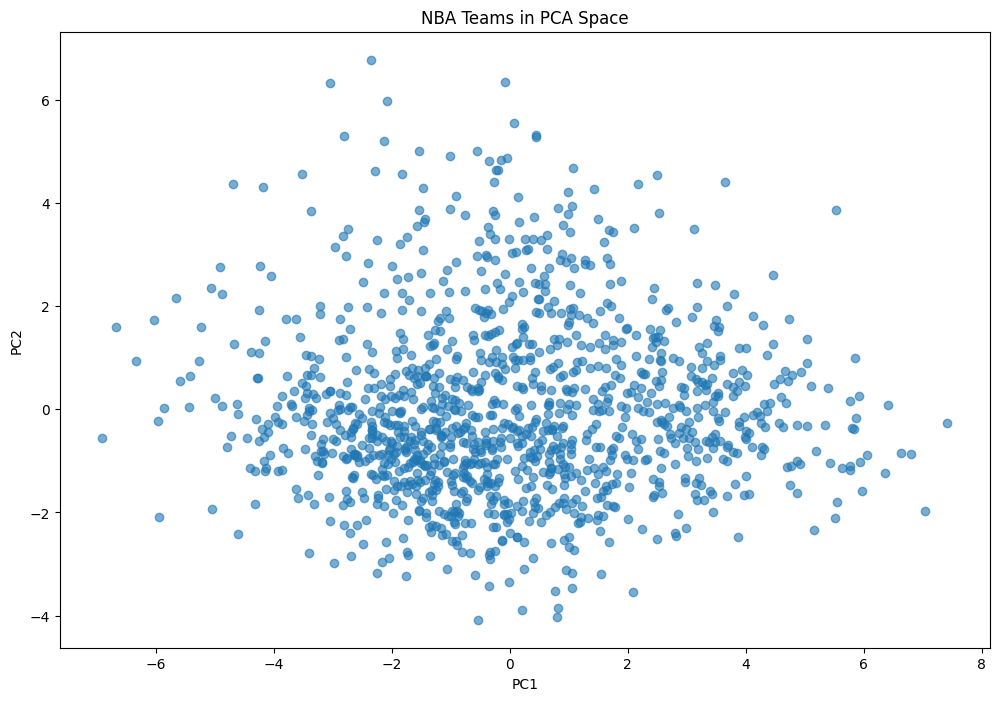

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.scatter(
    cluster_df["PC1"],
    cluster_df["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "NBA Teams in PCA Space"
)

plt.show()

In [13]:
def get_era(season):

    year = int(season[:4])

    if year < 1990:
        return "80s"

    elif year < 2000:
        return "90s"

    elif year < 2010:
        return "2000s"

    elif year < 2020:
        return "2010s"

    else:
        return "2020s"


cluster_df["ERA"] = (
    cluster_df["SEASON_STR"]
    .apply(get_era)
)

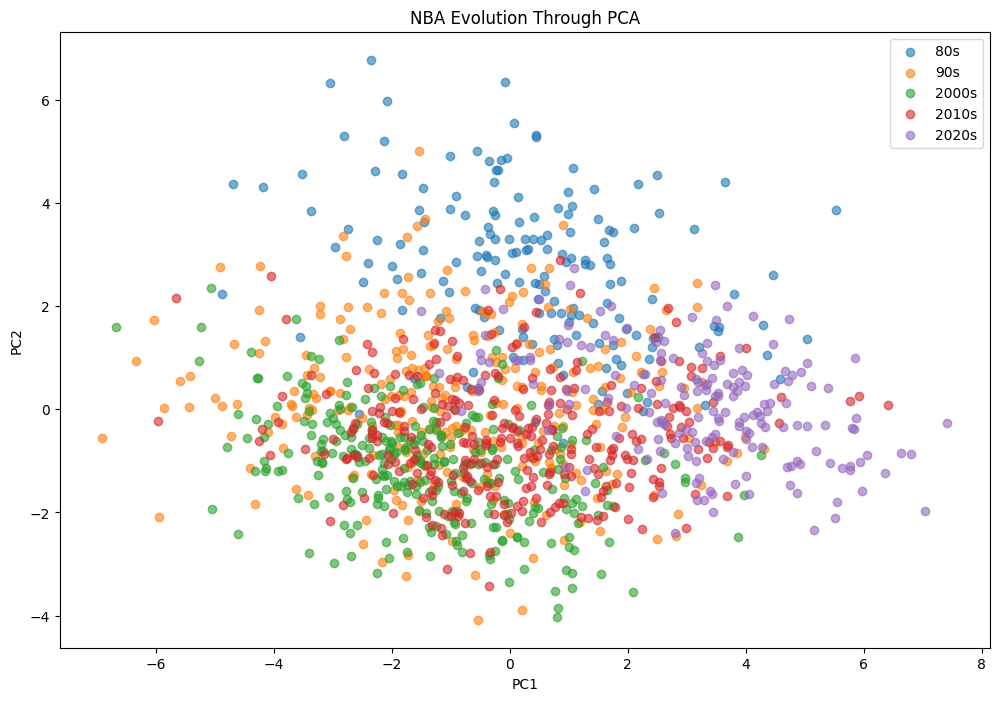

In [14]:
plt.figure(figsize=(12,8))

for era in cluster_df["ERA"].unique():

    subset = cluster_df[
        cluster_df["ERA"] == era
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=era,
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "NBA Evolution Through PCA"
)

plt.legend()

plt.show()

In [15]:
era_centers = (
    cluster_df
    .groupby("ERA")[["PC1","PC2"]]
    .mean()
)

era_centers

,PC1,PC2
ERA,,
2000s,-1.351642,-1.124723
2010s,0.053083,-0.524744
2020s,3.198010,0.068310
80s,0.391075,2.714875
90s,-0.907453,0.096109


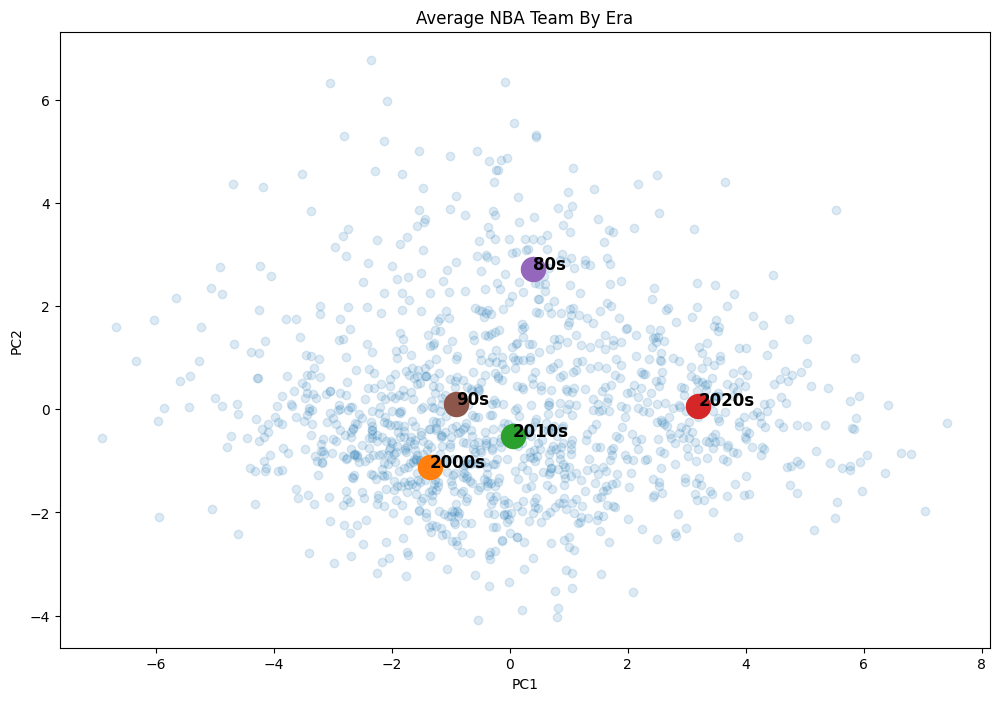

In [16]:
plt.figure(figsize=(12,8))

plt.scatter(
    cluster_df["PC1"],
    cluster_df["PC2"],
    alpha=0.15
)

for era, row in era_centers.iterrows():

    plt.scatter(
        row["PC1"],
        row["PC2"],
        s=300
    )

    plt.text(
        row["PC1"],
        row["PC2"],
        era,
        fontsize=12,
        weight="bold"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Average NBA Team By Era"
)

plt.show()

In [17]:
cluster_df[
    ["SEASON_STR","TEAM_NAME","PC1"]
].sort_values(
    "PC1",
    ascending=False
).head(20)


,SEASON_STR,TEAM_NAME,PC1
1152,2023-24,Indiana Pacers,7.417329
1136,2023-24,Boston Celtics,7.034274
1201,2025-26,Denver Nuggets,6.796746
1167,2024-25,Cleveland Cavaliers,6.633288
932,2016-17,Golden State Warriors,6.416063
1158,2023-24,Oklahoma City Thunder,6.355342
1059,2020-21,Brooklyn Nets,6.046762
1188,2024-25,Oklahoma City Thunder,5.964867
1141,2023-24,Denver Nuggets,5.931880
992,2018-19,Golden State Warriors,5.916301


In [18]:
cluster_df[
    ["SEASON_STR","TEAM_NAME","PC1"]
].sort_values(
    "PC1"
).head(20)

,SEASON_STR,TEAM_NAME,PC1
392,1998-99,Chicago Bulls,-6.912685
511,2002-03,Denver Nuggets,-6.675785
421,1999-00,Chicago Bulls,-6.338148
366,1997-98,Golden State Warriors,-6.035891
804,2011-12,Charlotte Bobcats,-5.959371
389,1998-99,Atlanta Hawks,-5.937429
397,1998-99,Los Angeles Clippers,-5.854865
883,2014-15,Philadelphia 76ers,-5.649848
414,1998-99,Vancouver Grizzlies,-5.587516
365,1997-98,Denver Nuggets,-5.445192


In [19]:
cluster_df[
    ["SEASON_STR","TEAM_NAME","PC2"]
].sort_values(
    "PC2",
    ascending=False
).head(20)

,SEASON_STR,TEAM_NAME,PC2
123,1988-89,Los Angeles Clippers,6.770693
61,1985-86,Phoenix Suns,6.331095
134,1988-89,San Antonio Spurs,6.319153
36,1984-85,Indiana Pacers,5.964720
7,1983-84,Houston Rockets,5.548361
64,1985-86,San Antonio Spurs,5.311708
71,1986-87,Cleveland Cavaliers,5.291543
30,1984-85,Houston Rockets,5.279719
3,1983-84,Chicago Bulls,5.187741
172,1990-91,Denver Nuggets,5.004232


In [20]:
cluster_df[
    ["SEASON_STR","TEAM_NAME","PC2"]
].sort_values(
    "PC2"
).head(20)

,SEASON_STR,TEAM_NAME,PC2
358,1996-97,Detroit Pistons,-4.078473
622,2005-06,Detroit Pistons,-4.023272
304,1995-96,Cleveland Cavaliers,-3.898262
707,2008-09,San Antonio Spurs,-3.856206
679,2007-08,Toronto Raptors,-3.541087
683,2007-08,Detroit Pistons,-3.528798
687,2008-09,Cleveland Cavaliers,-3.472468
820,2012-13,New York Knicks,-3.416627
677,2007-08,San Antonio Spurs,-3.341912
333,1996-97,Cleveland Cavaliers,-3.223358


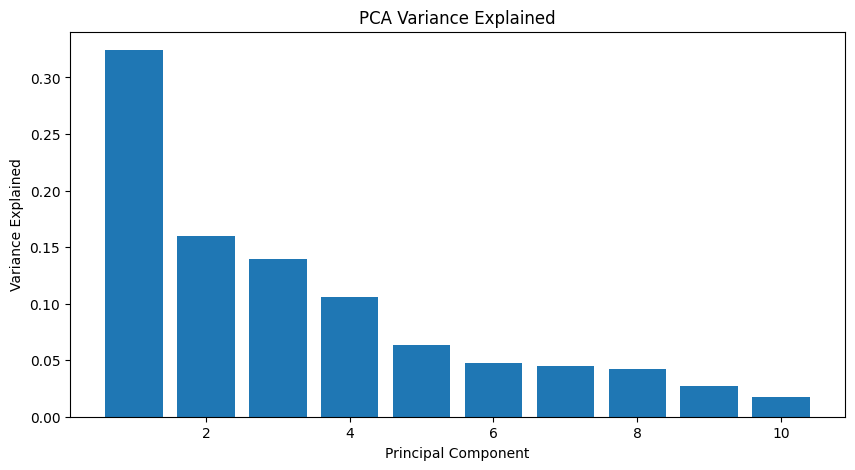

In [21]:
plt.figure(figsize=(10,5))

plt.bar(
    range(1,11),
    explained[:10]
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Variance Explained"
)

plt.title(
    "PCA Variance Explained"
)

plt.show()

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    results.append([k, score])

    print(
        f"K={k} | Silhouette={score:.4f}"
    )

K=2 | Silhouette=0.1925
K=3 | Silhouette=0.1941
K=4 | Silhouette=0.1564
K=5 | Silhouette=0.1400
K=6 | Silhouette=0.1339
K=7 | Silhouette=0.1216
K=8 | Silhouette=0.1203
K=9 | Silhouette=0.1150
K=10 | Silhouette=0.1112


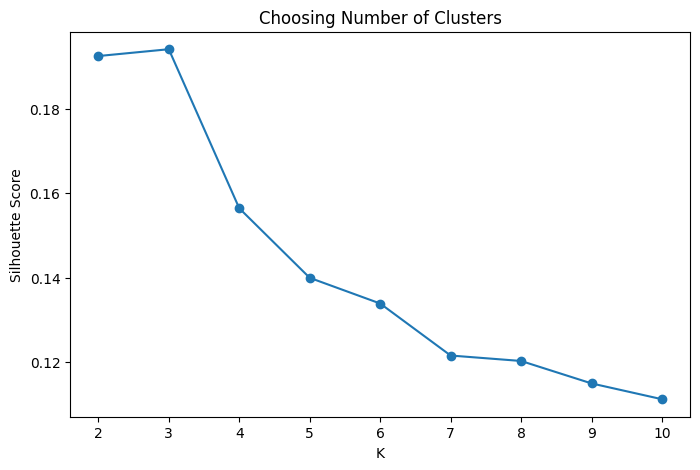

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

scores_df = pd.DataFrame(
    results,
    columns=["K","Silhouette"]
)

plt.figure(figsize=(8,5))

plt.plot(
    scores_df["K"],
    scores_df["Silhouette"],
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Silhouette Score")

plt.title(
    "Choosing Number of Clusters"
)

plt.show()

In [24]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

cluster_df["cluster"] = (
    kmeans.fit_predict(X_scaled)
)

In [25]:
cluster_df["cluster"] \
    .value_counts() \
    .sort_index()

,count
cluster,
0,239
1,273
2,160
3,227
4,326


In [26]:
cluster_summary = (
    cluster_df
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_summary

,pace,ortg,drtg,net_rating,efg_pct,ts_pct,fg_pct,fg3_pct,ft_pct,reb,ast,stl,blk,tov,assist_turnover_ratio,reb_diff,ast_diff,tov_diff
cluster,,,,,,,,,,,,,,,,,,
0,101.13,111.73,109.10,2.62,0.54,0.58,0.48,0.36,0.78,44.09,25.94,7.84,5.01,13.72,1.90,0.71,1.20,0.01
1,94.68,100.15,104.49,-4.34,0.47,0.51,0.44,0.33,0.74,41.90,20.67,7.72,4.92,14.97,1.39,-0.63,-1.77,-0.60
2,103.80,104.73,105.07,-0.34,0.49,0.54,0.48,0.27,0.75,43.80,25.48,8.76,5.48,16.83,1.52,0.22,0.04,-0.10
3,99.09,105.17,108.37,-3.20,0.50,0.54,0.46,0.35,0.77,41.90,22.79,7.93,4.58,14.35,1.60,-2.31,-1.59,0.21
4,94.00,105.12,101.76,3.35,0.50,0.54,0.46,0.36,0.75,42.50,22.21,7.81,5.09,13.84,1.61,1.26,1.38,0.31


In [27]:
cluster_z = pd.DataFrame(
    scaler.inverse_transform(
        kmeans.cluster_centers_
    ),
    columns=cluster_features
)

cluster_z.index.name = "cluster"

cluster_z

,pace,ortg,drtg,net_rating,efg_pct,ts_pct,fg_pct,fg3_pct,ft_pct,reb,ast,stl,blk,tov,assist_turnover_ratio,reb_diff,ast_diff,tov_diff
cluster,,,,,,,,,,,,,,,,,,
0,101.134170,111.726735,109.103352,2.623383,0.537978,0.575265,0.476522,0.360912,0.780062,44.090541,25.938221,7.841062,5.008318,13.721769,1.900343,0.710479,1.202239,0.014004
1,94.675540,100.154979,104.493318,-4.338338,0.470764,0.514956,0.440583,0.334612,0.739226,41.898157,20.666112,7.715063,4.920416,14.967061,1.387654,-0.632269,-1.767976,-0.595282
2,103.795654,104.727313,105.071610,-0.344297,0.489700,0.536258,0.481287,0.267800,0.753827,43.801447,25.480725,8.756239,5.484791,16.829998,1.524139,0.217191,0.044557,-0.097905
3,99.091169,105.170591,108.369862,-3.199271,0.501628,0.543233,0.457138,0.346351,0.767095,41.898724,22.793209,7.929525,4.575742,14.354660,1.595830,-2.309239,-1.589980,0.207373
4,93.998730,105.115816,101.764256,3.351560,0.495444,0.538500,0.458276,0.355590,0.751764,42.504492,22.214304,7.812948,5.090780,13.843533,1.611903,1.262426,1.381407,0.314907


In [28]:
for c in sorted(
    cluster_df["cluster"].unique()
):

    print(
        f"\n===== CLUSTER {c} ====="
    )

    display(

        cluster_df[
            cluster_df["cluster"] == c
        ][
            [
                "SEASON_STR",
                "TEAM_NAME"
            ]
        ].sample(
            15,
            random_state=42
        )

    )


===== CLUSTER 0 =====


,SEASON_STR,TEAM_NAME
196,1991-92,Cleveland Cavaliers
73,1986-87,Dallas Mavericks
1039,2019-20,Toronto Raptors
1063,2020-21,Philadelphia 76ers
1055,2020-21,Los Angeles Lakers
1142,2023-24,Golden State Warriors
1176,2024-25,Miami Heat
1026,2019-20,Miami Heat
97,1987-88,Denver Nuggets
1108,2022-23,New Orleans Pelicans



===== CLUSTER 1 =====


,SEASON_STR,TEAM_NAME
315,1995-96,New Jersey Nets
499,2001-02,Toronto Raptors
419,1999-00,Boston Celtics
729,2009-10,New Jersey Nets
733,2009-10,Philadelphia 76ers
541,2003-04,Golden State Warriors
728,2009-10,Minnesota Timberwolves
354,1996-97,Toronto Raptors
860,2013-14,Utah Jazz
836,2013-14,Boston Celtics



===== CLUSTER 2 =====


,SEASON_STR,TEAM_NAME
135,1988-89,Seattle SuperSonics
145,1989-90,Denver Nuggets
226,1992-93,Denver Nuggets
64,1985-86,San Antonio Spurs
116,1988-89,Boston Celtics
33,1984-85,Milwaukee Bucks
128,1988-89,New York Knicks
60,1985-86,Philadelphia 76ers
123,1988-89,Los Angeles Clippers
227,1992-93,Golden State Warriors



===== CLUSTER 3 =====


,SEASON_STR,TEAM_NAME
126,1988-89,Milwaukee Bucks
939,2016-17,Brooklyn Nets
146,1989-90,Golden State Warriors
850,2013-14,New York Knicks
955,2017-18,Atlanta Hawks
612,2005-06,Philadelphia 76ers
876,2014-15,Miami Heat
699,2008-09,New Jersey Nets
281,1994-95,Golden State Warriors
193,1990-91,Charlotte Hornets



===== CLUSTER 4 =====


,SEASON_STR,TEAM_NAME
775,2011-12,Atlanta Hawks
471,2000-01,Utah Jazz
800,2011-12,Utah Jazz
235,1992-93,New York Knicks
439,1999-00,San Antonio Spurs
746,2010-11,Boston Celtics
858,2013-14,Oklahoma City Thunder
695,2008-09,Los Angeles Lakers
707,2008-09,San Antonio Spurs
458,2000-01,Milwaukee Bucks


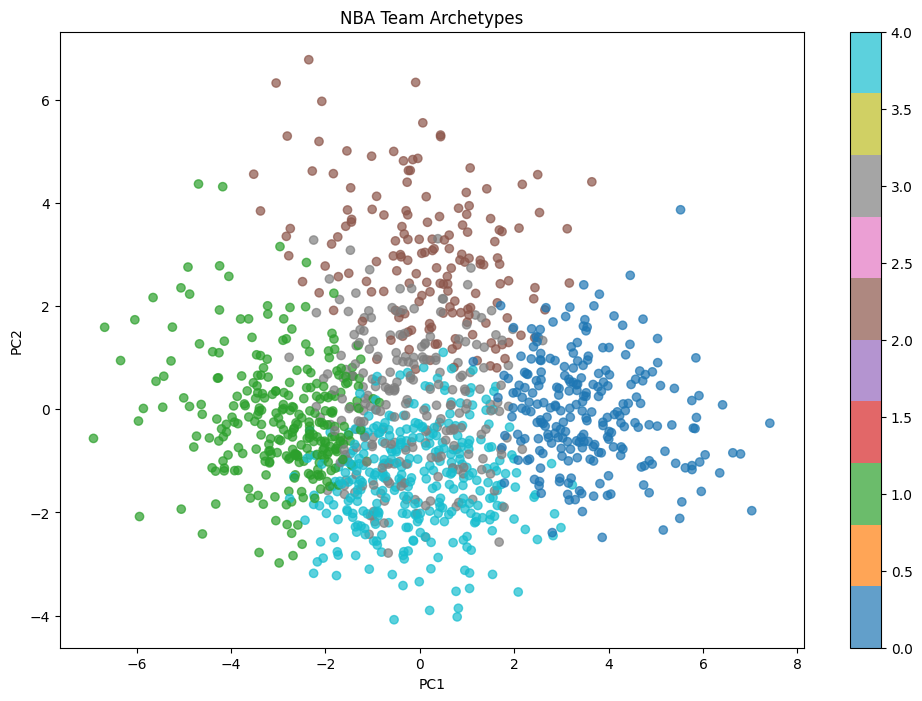

In [29]:
plt.figure(figsize=(12,8))

plt.scatter(
    cluster_df["PC1"],
    cluster_df["PC2"],
    c=cluster_df["cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "NBA Team Archetypes"
)

plt.colorbar()

plt.show()

In [30]:
cluster_df["ERA"] = (
    cluster_df["SEASON_STR"]
    .apply(get_era)
)

In [31]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["ERA"]
)

ERA,2000s,2010s,2020s,80s,90s
cluster,,,,,
0,8,51,143,19,18
1,128,54,0,7,84
2,2,3,0,119,36
3,40,85,36,19,47
4,120,107,1,3,95


In [32]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["ERA"],
    normalize="index"
).round(3)

ERA,2000s,2010s,2020s,80s,90s
cluster,,,,,
0,0.033,0.213,0.598,0.079,0.075
1,0.469,0.198,0.000,0.026,0.308
2,0.012,0.019,0.000,0.744,0.225
3,0.176,0.374,0.159,0.084,0.207
4,0.368,0.328,0.003,0.009,0.291


In [33]:
famous = [

    ("1995-96", "Chicago Bulls"),
    ("1985-86", "Boston Celtics"),
    ("2016-17", "Golden State Warriors"),
    ("2003-04", "Detroit Pistons"),
    ("2013-14", "San Antonio Spurs"),
    ("2023-24", "Boston Celtics")

]

for season, team in famous:

    row = cluster_df[
        (cluster_df["SEASON_STR"] == season) &
        (cluster_df["TEAM_NAME"] == team)
    ]

    print(
        season,
        team,
        row["cluster"].iloc[0]
    )

1995-96 Chicago Bulls 4
1985-86 Boston Celtics 0
2016-17 Golden State Warriors 0
2003-04 Detroit Pistons 4
2013-14 San Antonio Spurs 0
2023-24 Boston Celtics 0


In [34]:
for c in range(5):

    print(f"\nCLUSTER {c}")

    display(
        cluster_df[
            cluster_df["cluster"] == c
        ][
            [
                "SEASON_STR",
                "TEAM_NAME",
                "ortg",
                "drtg",
                "net_rating"
            ]
        ]
        .sample(20, random_state=42)
    )


CLUSTER 0


,SEASON_STR,TEAM_NAME,ortg,drtg,net_rating
196,1991-92,Cleveland Cavaliers,111.201522,106.102921,5.098601
73,1986-87,Dallas Mavericks,111.963950,106.373006,5.590944
1039,2019-20,Toronto Raptors,108.800200,103.408714,5.391487
1063,2020-21,Philadelphia 76ers,111.779899,105.995820,5.784079
1055,2020-21,Los Angeles Lakers,107.470889,105.063846,2.407043
1142,2023-24,Golden State Warriors,114.921234,112.558243,2.362991
1176,2024-25,Miami Heat,111.289727,111.774729,-0.485002
1026,2019-20,Miami Heat,110.689726,107.712574,2.977152
97,1987-88,Denver Nuggets,106.982406,103.929165,3.053241
1108,2022-23,New Orleans Pelicans,112.061595,110.213569,1.848026



CLUSTER 1


,SEASON_STR,TEAM_NAME,ortg,drtg,net_rating
315,1995-96,New Jersey Nets,99.839405,104.348029,-4.508625
499,2001-02,Toronto Raptors,99.876306,100.507396,-0.631090
419,1999-00,Boston Celtics,102.465409,103.245283,-0.779874
729,2009-10,New Jersey Nets,98.782884,107.779482,-8.996598
733,2009-10,Philadelphia 76ers,103.460523,108.141356,-4.680833
541,2003-04,Golden State Warriors,101.239921,102.034063,-0.794142
728,2009-10,Minnesota Timberwolves,99.676748,108.951098,-9.274350
354,1996-97,Toronto Raptors,102.172653,105.513591,-3.340937
860,2013-14,Utah Jazz,100.478052,108.056631,-7.578579
836,2013-14,Boston Celtics,100.472264,104.795151,-4.322887



CLUSTER 2


,SEASON_STR,TEAM_NAME,ortg,drtg,net_rating
135,1988-89,Seattle SuperSonics,107.725414,105.605767,2.119647
145,1989-90,Denver Nuggets,105.066945,104.203972,0.862973
226,1992-93,Denver Nuggets,102.417363,104.115217,-1.697853
64,1985-86,San Antonio Spurs,103.826417,106.555783,-2.729366
116,1988-89,Boston Celtics,107.251099,106.518970,0.732129
33,1984-85,Milwaukee Bucks,107.629345,101.751975,5.877370
128,1988-89,New York Knicks,107.730657,104.742687,2.987970
60,1985-86,Philadelphia 76ers,106.469307,104.137563,2.331745
123,1988-89,Los Angeles Clippers,97.999955,107.145268,-9.145313
227,1992-93,Golden State Warriors,106.264589,107.219485,-0.954896



CLUSTER 3


,SEASON_STR,TEAM_NAME,ortg,drtg,net_rating
126,1988-89,Milwaukee Bucks,106.921846,104.174389,2.747456
939,2016-17,Brooklyn Nets,102.088642,108.832939,-6.744298
146,1989-90,Golden State Warriors,106.507051,109.378072,-2.871021
850,2013-14,New York Knicks,105.342317,106.653832,-1.311515
955,2017-18,Atlanta Hawks,102.369064,107.638984,-5.269921
612,2005-06,Philadelphia 76ers,103.681541,105.563239,-1.881698
876,2014-15,Miami Heat,102.798394,105.430263,-2.631869
699,2008-09,New Jersey Nets,105.794263,108.715149,-2.920886
281,1994-95,Golden State Warriors,104.600642,109.959207,-5.358565
193,1990-91,Charlotte Hornets,102.354096,107.576243,-5.222148



CLUSTER 4


,SEASON_STR,TEAM_NAME,ortg,drtg,net_rating
775,2011-12,Atlanta Hawks,101.751332,98.657004,3.094328
471,2000-01,Utah Jazz,104.565197,100.037811,4.527386
800,2011-12,Utah Jazz,103.418759,104.001071,-0.582313
235,1992-93,New York Knicks,103.832040,98.562667,5.269373
439,1999-00,San Antonio Spurs,102.728760,96.699871,6.028889
746,2010-11,Boston Celtics,104.956972,99.326045,5.630927
858,2013-14,Oklahoma City Thunder,107.553444,102.546318,5.007126
695,2008-09,Los Angeles Lakers,109.004653,101.531304,7.473349
707,2008-09,San Antonio Spurs,106.239750,102.609529,3.630220
458,2000-01,Milwaukee Bucks,106.668091,103.002778,3.665313


In [35]:
cluster_df[
    cluster_df["cluster"] == 0
][
    ["SEASON_STR","TEAM_NAME"]
].head(50)

,SEASON_STR,TEAM_NAME
24,1984-85,Boston Celtics
27,1984-85,Dallas Mavericks
32,1984-85,Los Angeles Lakers
47,1985-86,Boston Celtics
55,1985-86,Los Angeles Lakers
70,1986-87,Boston Celtics
73,1986-87,Dallas Mavericks
78,1986-87,Los Angeles Lakers
93,1987-88,Boston Celtics
97,1987-88,Denver Nuggets


In [36]:
cluster_df[
    cluster_df["cluster"] == 4
][
    ["SEASON_STR","TEAM_NAME"]
].head(50)

,SEASON_STR,TEAM_NAME
138,1988-89,Detroit Pistons
142,1989-90,Cleveland Cavaliers
165,1989-90,Detroit Pistons
176,1990-91,Los Angeles Lakers
192,1990-91,Detroit Pistons
208,1991-92,New York Knicks
219,1991-92,Detroit Pistons
224,1992-93,Chicago Bulls
228,1992-93,Houston Rockets
235,1992-93,New York Knicks


In [37]:
cluster_names = {
    0: "Offensive Dynasty",
    1: "Struggling Grindhouse",
    2: "Showtime Run-and-Gun",
    3: "Average Contender",
    4: "Defensive Dynasty"
}

In [38]:
cluster_df["cluster_name"] = (
    cluster_df["cluster"]
    .map(cluster_names)
)

In [39]:
cluster_df[
    [
        "SEASON_STR",
        "TEAM_NAME",
        "cluster",
        "cluster_name"
    ]
].head()

,SEASON_STR,TEAM_NAME,cluster,cluster_name
0,1983-84,Atlanta Hawks,2,Showtime Run-and-Gun
1,1983-84,Boston Celtics,2,Showtime Run-and-Gun
2,1983-84,Cleveland Cavaliers,2,Showtime Run-and-Gun
3,1983-84,Chicago Bulls,2,Showtime Run-and-Gun
4,1983-84,Dallas Mavericks,2,Showtime Run-and-Gun


In [40]:
cluster_df.to_csv(
    "nba_team_clusters.csv",
    index=False
)

In [41]:
cluster_df["PC1"] = X_pca[:,0]
cluster_df["PC2"] = X_pca[:,1]